In [1]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0))

CUDA available: True
GPU name: NVIDIA GeForce RTX 4060


In [2]:
import os
import numpy as np
import pandas as pd
from PIL import Image

import torch
import copy

import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [4]:
label_index = {
    "Benign": 0,
    "Early": 1,
    "Pre": 2,
    "Pro": 3
}

index_label = {v: k for k, v in label_index.items()}
NUM_CLASSES = 4


In [5]:
def create_df(base_path):
    data = {"image": [], "label": []}
    for cls in os.listdir(base_path):
        cls_path = os.path.join(base_path, cls)
        for img in os.listdir(cls_path):
            data["image"].append(os.path.join(cls_path, img))
            data["label"].append(label_index[cls])
    return pd.DataFrame(data)


In [6]:
train_df = create_df(r"D:\Download\likomia\data_split\train")
val_df   = create_df(r"D:\Download\likomia\data_split\val")
test_df  = create_df(r"D:\Download\likomia\data_split\test")


In [7]:
class CloudDS(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, "image"]
        label = self.df.loc[idx, "label"]

        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        return image, label


In [8]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [9]:
BATCH_SIZE = 32

train_dl = DataLoader(CloudDS(train_df, train_transform),
                      batch_size=BATCH_SIZE, shuffle=True)

val_dl   = DataLoader(CloudDS(val_df, val_test_transform),
                      batch_size=BATCH_SIZE, shuffle=False)

test_dl  = DataLoader(CloudDS(test_df, val_test_transform),
                      batch_size=BATCH_SIZE, shuffle=False)



In [10]:
model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)

# Freeze entire backbone
for param in model.parameters():
    param.requires_grad = False

# Replace classifier
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)

# Train classifier only (phase 1)
for param in model.fc.parameters():
    param.requires_grad = True

model = model.to(device)
print(sum(p.numel() for p in model.parameters() if p.requires_grad),
      "trainable parameters (BEFORE unfreezing)")


8196 trainable parameters (BEFORE unfreezing)


In [11]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.fc.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", patience=3, factor=0.3
)



In [12]:
class EarlyStopping:
    def __init__(self, patience=6):
        self.patience = patience
        self.best_loss = np.inf
        self.counter = 0
        self.stop = False

    def __call__(self, loss):
        if loss < self.best_loss:
            self.best_loss = loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True


In [13]:
EPOCHS = 30
UNFREEZE_EPOCH = 10

early_stopping = EarlyStopping()
best_val_acc = 0
best_model_wts = None


In [31]:
train_loss_hist = []
val_loss_hist   = []
train_acc_hist  = []
val_acc_hist    = []

for epoch in range(EPOCHS):

    if epoch == UNFREEZE_EPOCH:
        print("Unfreezing ResNet layer4")

        for param in model.layer4.parameters():
            param.requires_grad = True

        optimizer = torch.optim.AdamW([
            {"params": model.layer4.parameters(), "lr": 1e-5},
            {"params": model.fc.parameters(),     "lr": 1e-4}
        ], weight_decay=1e-4)

        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", patience=3, factor=0.3
        )

    model.train()
    train_loss, correct, total = 0, 0, 0

    for x, y in train_dl:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        correct += (out.argmax(1) == y).sum().item()
        total += y.size(0)

    train_loss /= len(train_dl)
    train_acc = correct / total

    model.eval()
    val_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for x, y in val_dl:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)

            val_loss += loss.item()
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)

    val_loss /= len(val_dl)
    val_acc = correct / total

    scheduler.step(val_loss)

    
    train_loss_hist.append(train_loss)
    val_loss_hist.append(val_loss)
    train_acc_hist.append(train_acc)
    val_acc_hist.append(val_acc)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

    if early_stopping.stop and epoch >= UNFREEZE_EPOCH:
        print("Early stopping triggered")
        break


Epoch [1/30] | Train Loss: 0.0917 | Train Acc: 0.9675 | Val Loss: 0.0564 | Val Acc: 0.9794
Epoch [2/30] | Train Loss: 0.0835 | Train Acc: 0.9732 | Val Loss: 0.0360 | Val Acc: 0.9897
Epoch [3/30] | Train Loss: 0.0805 | Train Acc: 0.9785 | Val Loss: 0.0606 | Val Acc: 0.9856
Epoch [4/30] | Train Loss: 0.0961 | Train Acc: 0.9688 | Val Loss: 0.0618 | Val Acc: 0.9856
Epoch [5/30] | Train Loss: 0.0853 | Train Acc: 0.9745 | Val Loss: 0.0479 | Val Acc: 0.9877
Epoch [6/30] | Train Loss: 0.0737 | Train Acc: 0.9776 | Val Loss: 0.0586 | Val Acc: 0.9877
Epoch [7/30] | Train Loss: 0.0713 | Train Acc: 0.9754 | Val Loss: 0.0441 | Val Acc: 0.9897
Epoch [8/30] | Train Loss: 0.0750 | Train Acc: 0.9771 | Val Loss: 0.0387 | Val Acc: 0.9877
Epoch [9/30] | Train Loss: 0.0932 | Train Acc: 0.9662 | Val Loss: 0.0460 | Val Acc: 0.9835
Epoch [10/30] | Train Loss: 0.0771 | Train Acc: 0.9749 | Val Loss: 0.0358 | Val Acc: 0.9897
Unfreezing ResNet layer4
Epoch [11/30] | Train Loss: 0.0630 | Train Acc: 0.9811 | Val Los

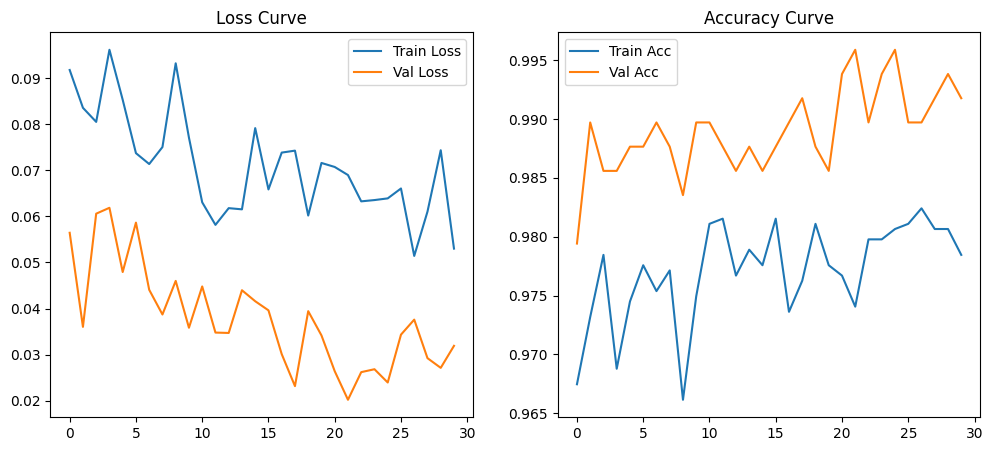

In [32]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_loss_hist, label="Train Loss")
plt.plot(val_loss_hist, label="Val Loss")
plt.legend()
plt.title("Loss Curve")

plt.subplot(1,2,2)
plt.plot(train_acc_hist, label="Train Acc")
plt.plot(val_acc_hist, label="Val Acc")
plt.legend()
plt.title("Accuracy Curve")

plt.show()


In [33]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

y_true = []
y_pred = []

with torch.no_grad():
    for x, y in test_dl:
        x = x.to(device)
        outputs = model(x)
        preds = outputs.argmax(dim=1).cpu().numpy()

        y_pred.extend(preds)
        y_true.extend(y.numpy())


In [34]:
acc = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="weighted")
recall = recall_score(y_true, y_pred, average="weighted")
f1 = f1_score(y_true, y_pred, average="weighted")

print(f"Test Accuracy : {acc:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall   : {recall:.4f}")
print(f"Test F1-score : {f1:.4f}")


Test Accuracy : 0.9837
Test Precision: 0.9840
Test Recall   : 0.9837
Test F1-score : 0.9836


In [35]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=list(index_label.values()),
        digits=4
    )
)


              precision    recall  f1-score   support

      Benign     0.9857    0.9200    0.9517        75
       Early     0.9613    1.0000    0.9803       149
         Pre     1.0000    0.9931    0.9965       145
         Pro     0.9918    0.9918    0.9918       122

    accuracy                         0.9837       491
   macro avg     0.9847    0.9762    0.9801       491
weighted avg     0.9840    0.9837    0.9836       491



In [36]:
precision_macro = precision_score(y_true, y_pred, average="macro")
recall_macro = recall_score(y_true, y_pred, average="macro")
f1_macro = f1_score(y_true, y_pred, average="macro")

print(f"Macro Precision: {precision_macro:.4f}")
print(f"Macro Recall   : {recall_macro:.4f}")
print(f"Macro F1-score : {f1_macro:.4f}")


Macro Precision: 0.9847
Macro Recall   : 0.9762
Macro F1-score : 0.9801


In [37]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import numpy as np


In [38]:
y_true = []
y_pred = []
y_prob = []

model.eval()
with torch.no_grad():
    for x, y in test_dl:
        x = x.to(device)
        outputs = model(x)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()

        y_prob.extend(probs)
        y_pred.extend(np.argmax(probs, axis=1))
        y_true.extend(y.numpy())


In [39]:
y_true = np.array(y_true)
y_prob = np.array(y_prob)


In [40]:
y_true_bin = label_binarize(y_true, classes=[0, 1, 2, 3])


In [41]:
roc_auc_per_class = roc_auc_score(
    y_true_bin,
    y_prob,
    average=None,
    multi_class="ovr"
)

roc_auc_macro = roc_auc_score(
    y_true_bin,
    y_prob,
    average="macro",
    multi_class="ovr"
)

roc_auc_weighted = roc_auc_score(
    y_true_bin,
    y_prob,
    average="weighted",
    multi_class="ovr"
)


In [42]:
for i, cls in index_label.items():
    print(f"ROC–AUC ({cls}): {roc_auc_per_class[i]:.4f}")

print(f"Macro ROC–AUC   : {roc_auc_macro:.4f}")
print(f"Weighted ROC–AUC: {roc_auc_weighted:.4f}")


ROC–AUC (Benign): 0.9976
ROC–AUC (Early): 0.9997
ROC–AUC (Pre): 1.0000
ROC–AUC (Pro): 1.0000
Macro ROC–AUC   : 0.9993
Weighted ROC–AUC: 0.9995


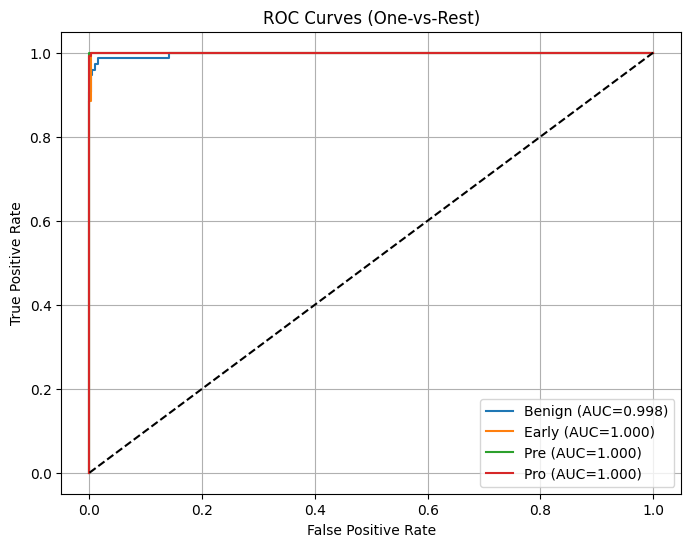

In [43]:
plt.figure(figsize=(8, 6))

for i, cls in index_label.items():
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    plt.plot(fpr, tpr, label=f"{cls} (AUC={roc_auc_per_class[i]:.3f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (One-vs-Rest)")
plt.legend()
plt.grid(True)
plt.show()


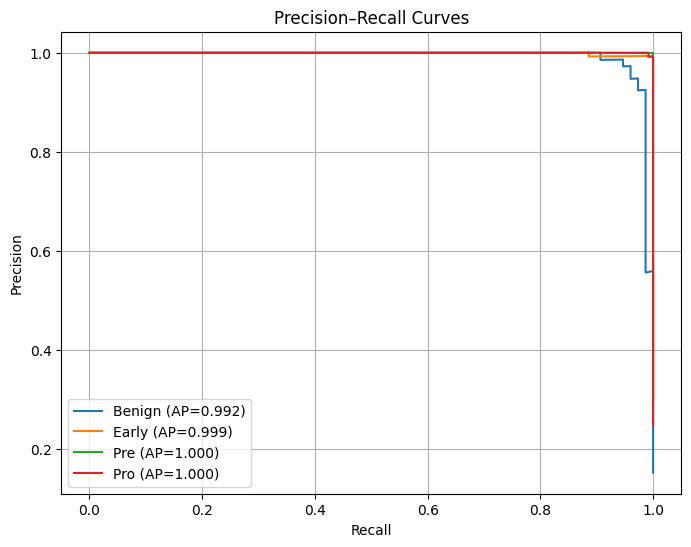

In [44]:
plt.figure(figsize=(8, 6))

for i, cls in index_label.items():
    precision, recall, _ = precision_recall_curve(
        y_true_bin[:, i], y_prob[:, i]
    )
    ap = average_precision_score(y_true_bin[:, i], y_prob[:, i])
    plt.plot(recall, precision, label=f"{cls} (AP={ap:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves")
plt.legend()
plt.grid(True)
plt.show()


In [45]:
y_true = []
y_pred = []

model.eval()
with torch.no_grad():
    for x, y in test_dl:
        x = x.to(device)
        outputs = model(x)
        preds = outputs.argmax(dim=1).cpu().numpy()

        y_pred.extend(preds)
        y_true.extend(y.numpy())


In [46]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_true, y_pred)


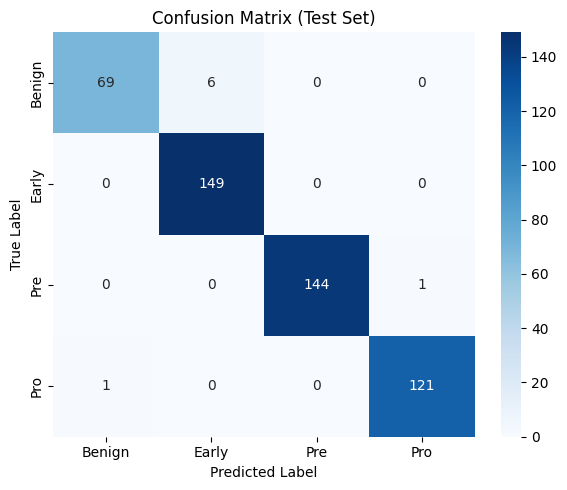

In [47]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=list(index_label.values()),
    yticklabels=list(index_label.values())
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Test Set)")
plt.tight_layout()
plt.show()


In [48]:
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)


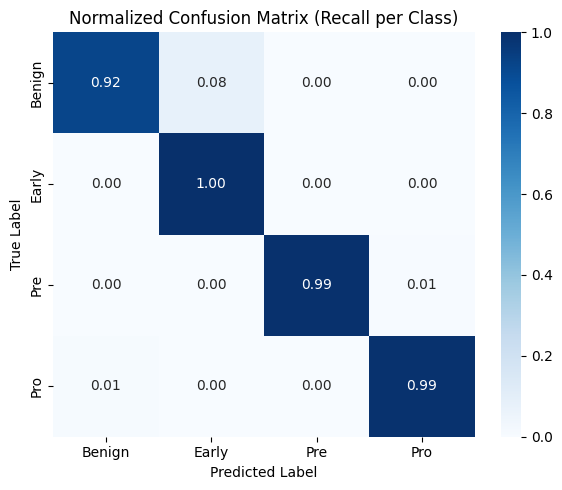

In [49]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=list(index_label.values()),
    yticklabels=list(index_label.values())
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized Confusion Matrix (Recall per Class)")
plt.tight_layout()
plt.show()


In [51]:
model.load_state_dict(best_model_wts)
model.eval()


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [57]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])

test_dir =  r"D:\Download\likomia\data_split\test"

test_dataset = datasets.ImageFolder(
    root=test_dir,
    transform=test_transform
)

test_dl = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

class_names = test_dataset.classes
print(class_names)



['Benign', 'Early', 'Pre', 'Pro']


In [58]:
model.load_state_dict(best_model_wts)
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for x, y in test_dl:
        x, y = x.to(device), y.to(device)
        outputs = model(x)
        preds = outputs.argmax(dim=1)

        correct += (preds == y).sum().item()
        total += y.size(0)

test_acc = correct / total
print(f"Test Accuracy: {test_acc:.4f}")


Test Accuracy: 0.9857


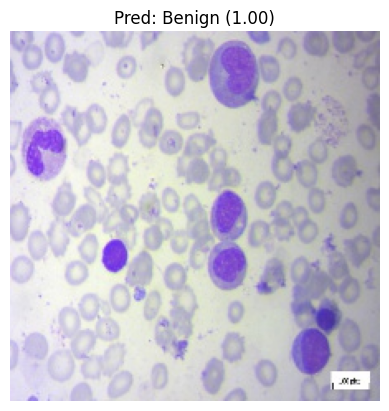

In [66]:
from PIL import Image
import matplotlib.pyplot as plt
import torch.nn.functional as F

img_path = "D:/Download/likomia/data_split/test/Benign/WBC-Benign-006.jpg"  # change name
img = Image.open(img_path).convert("RGB")

x = test_transform(img).unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    output = model(x)
    probs = F.softmax(output, dim=1)
    pred = probs.argmax(dim=1).item()
    conf = probs.max().item()

plt.imshow(img)
plt.title(f"Pred: {class_names[pred]} ({conf:.2f})")
plt.axis("off")
plt.show()


In [74]:
target_layer = model.layer4[-1]


In [75]:
import torch
import torch.nn.functional as F
import numpy as np
import cv2

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output.detach()

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, x, class_idx=None):
        self.model.zero_grad()
        output = self.model(x)

        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        score = output[:, class_idx]
        score.backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1)

        cam = F.relu(cam)
        cam = cam.squeeze().cpu().numpy()

        cam = cv2.resize(cam, (224, 224))
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

        return cam, class_idx


In [76]:
from PIL import Image
import matplotlib.pyplot as plt

img_path = "D:/Download/likomia/data_split/test/Benign/WBC-Benign-006.jpg"
img = Image.open(img_path).convert("RGB")

x = test_transform(img).unsqueeze(0).to(device)

gradcam = GradCAM(model, target_layer)

model.eval()
cam, pred_class = gradcam.generate(x)

print("Predicted class:", class_names[pred_class])


C:\Users\User\anaconda3\envs\torch_gpu\lib\site-packages\torch\nn\modules\module.py:1827: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


Predicted class: Benign


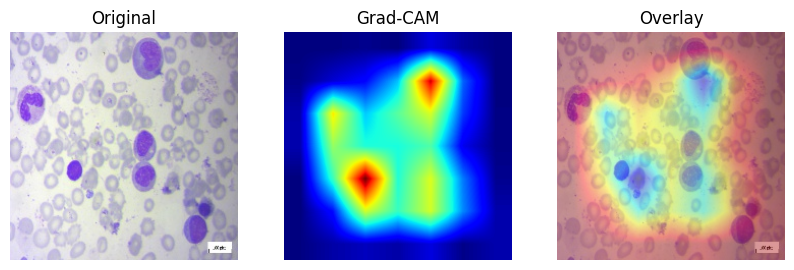

In [77]:
img_np = np.array(img.resize((224, 224)))
heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)

overlay = cv2.addWeighted(img_np, 0.6, heatmap, 0.4, 0)

plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.imshow(img_np)
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(cam, cmap="jet")
plt.title("Grad-CAM")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(overlay)
plt.title("Overlay")
plt.axis("off")

plt.show()


In [80]:
from PIL import Image
import matplotlib.pyplot as plt

img_path = "D:/Download/likomia/data_split/test/Pro/WBC-Malignant-Pro-020.jpg"
img = Image.open(img_path).convert("RGB")

x = test_transform(img).unsqueeze(0).to(device)

gradcam = GradCAM(model, target_layer)

model.eval()
cam, pred_class = gradcam.generate(x)

print("Predicted class:", class_names[pred_class])


Predicted class: Pro


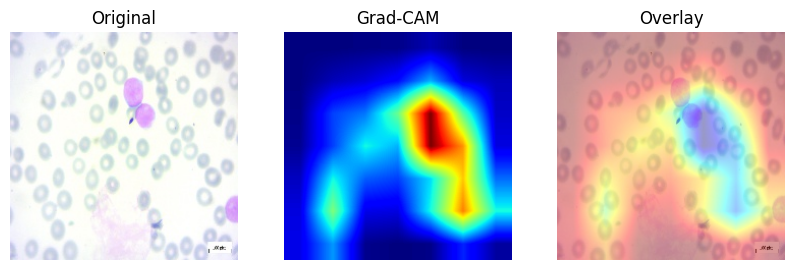

In [81]:
img_np = np.array(img.resize((224, 224)))
heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)

overlay = cv2.addWeighted(img_np, 0.6, heatmap, 0.4, 0)

plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.imshow(img_np)
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(cam, cmap="jet")
plt.title("Grad-CAM")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(overlay)
plt.title("Overlay")
plt.axis("off")

plt.show()


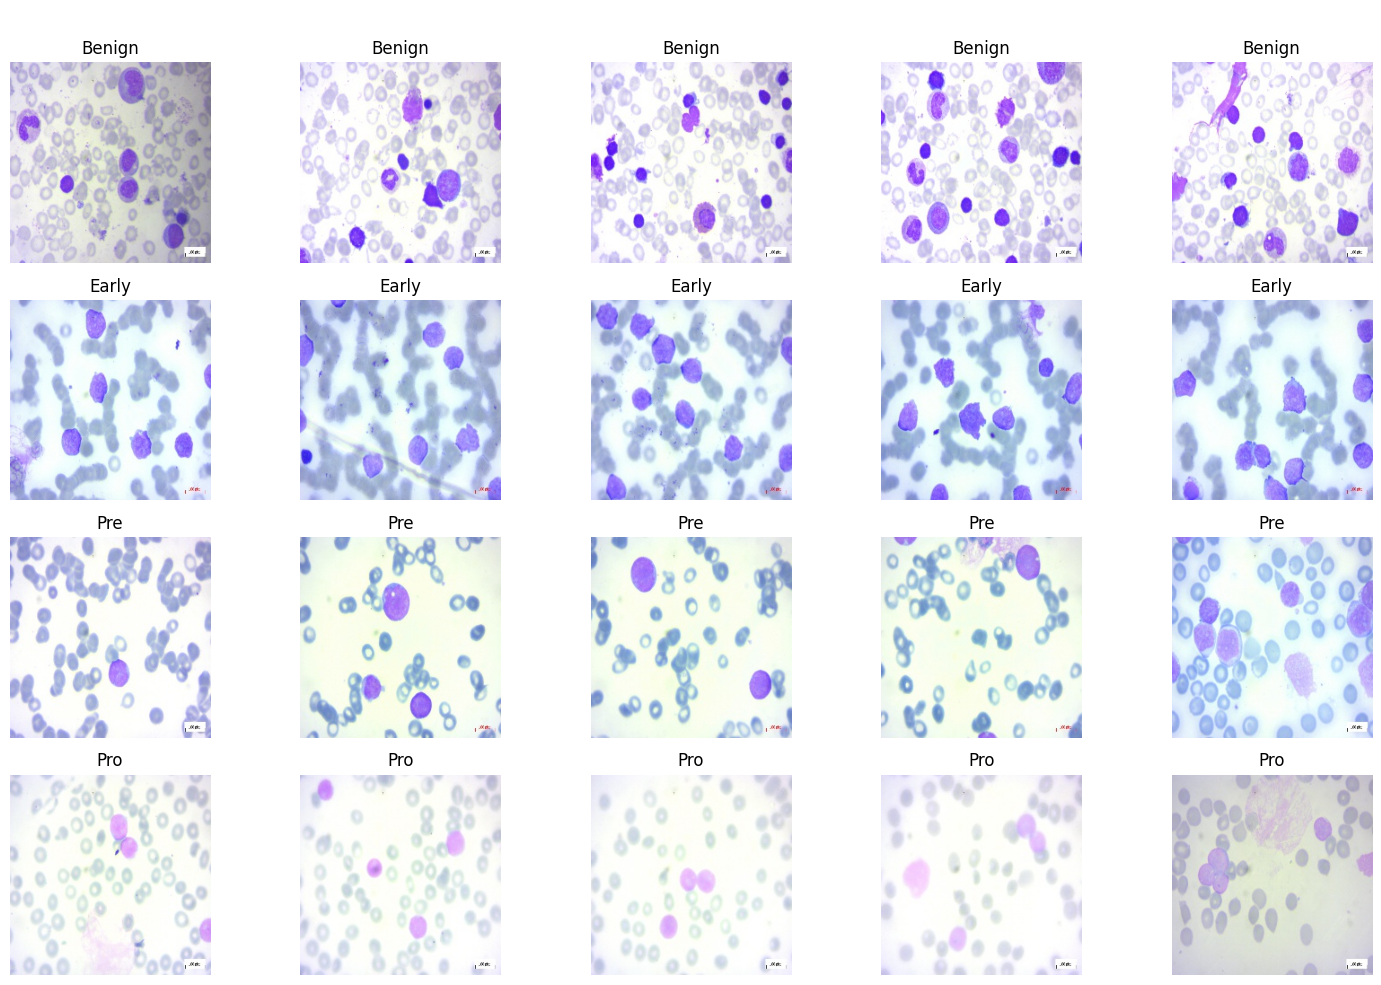

In [84]:
import os
import matplotlib.pyplot as plt
from PIL import Image

test_dir = "D:/Download/likomia/data_split/test"
classes = os.listdir(test_dir)

images_per_class = 5  

plt.figure(figsize=(15, 10))

plot_idx = 1
for cls in classes:
    cls_path = os.path.join(test_dir, cls)
    img_names = os.listdir(cls_path)[:images_per_class]

    for img_name in img_names:
        img_path = os.path.join(cls_path, img_name)
        img = Image.open(img_path).convert("RGB")

        plt.subplot(len(classes), images_per_class, plot_idx)
        plt.imshow(img)
        plt.title(cls)
        plt.axis("off")
        plot_idx += 1

plt.suptitle(" ", fontsize=16)
plt.tight_layout()
plt.show()


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6384109..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6505601..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9131652..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8081232..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6212862..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6505601..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9306722..2.64].
Clipping input data 

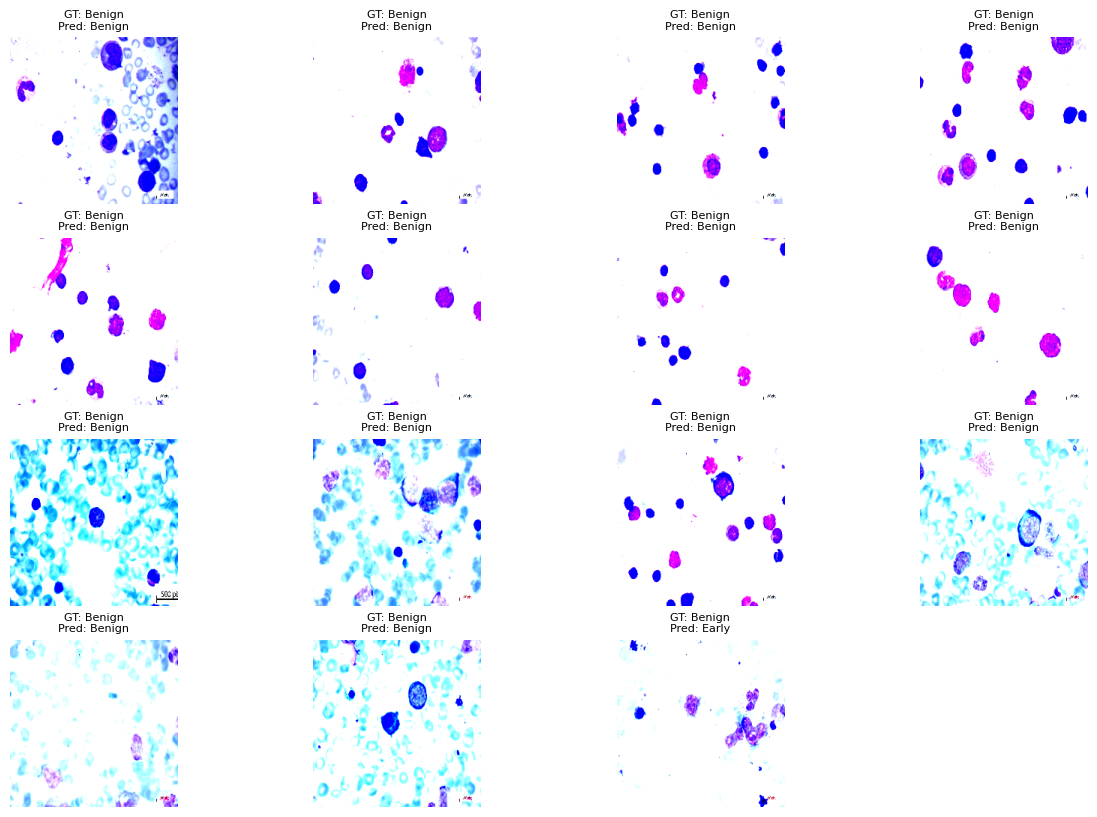

In [89]:
import torch

model.eval()

plt.figure(figsize=(15, 10))
idx = 1

for x, y in test_dl:
    x = x.to(device)

    with torch.no_grad():
        preds = model(x).argmax(dim=1)

    for i in range(min(15, x.size(0))):
        img = x[i].cpu().permute(1, 2, 0)
        plt.subplot(4, 4, idx)
        plt.imshow(img)
        plt.title(
            f"GT: {class_names[y[i]]}\nPred: {class_names[preds[i]]}",
            fontsize=8
        )
        plt.axis("off")
        idx += 1

    break

plt.show()


In [90]:
import torch
import torch.nn.functional as F
import numpy as np
import cv2

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        self.target_layer.register_forward_hook(self._forward_hook)
        self.target_layer.register_backward_hook(self._backward_hook)

    def _forward_hook(self, module, input, output):
        self.activations = output.detach()

    def _backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, x, class_idx=None):
        self.model.zero_grad()
        output = self.model(x)

        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        score = output[:, class_idx]
        score.backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1)
        cam = F.relu(cam)

        cam = cam.squeeze().cpu().numpy()
        cam = cv2.resize(cam, (224, 224))
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

        return cam, class_idx


In [91]:
import os
from PIL import Image
import matplotlib.pyplot as plt

test_dir = "D:/Download/likomia/data_split/test"
classes = sorted(os.listdir(test_dir))

target_layer = model.layer4[-1]
gradcam = GradCAM(model, target_layer)

model.eval()


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 


Class: Benign


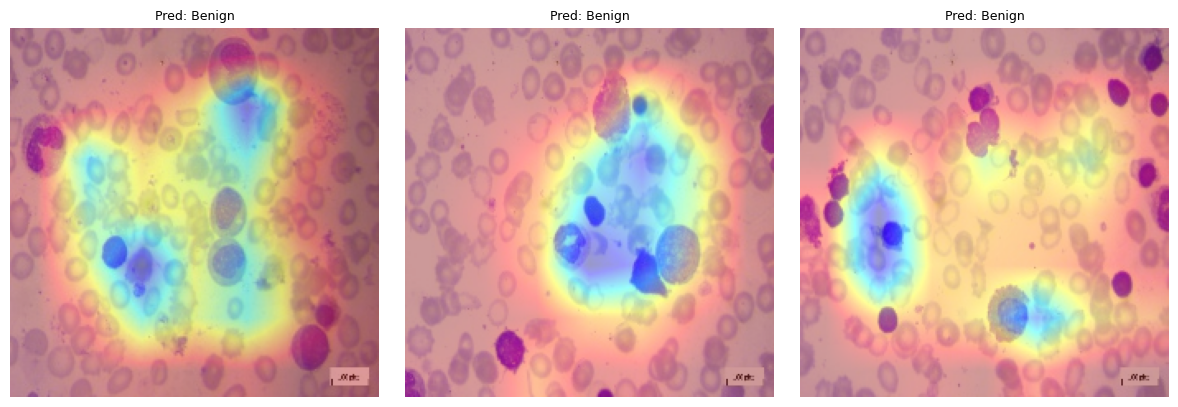


Class: Early


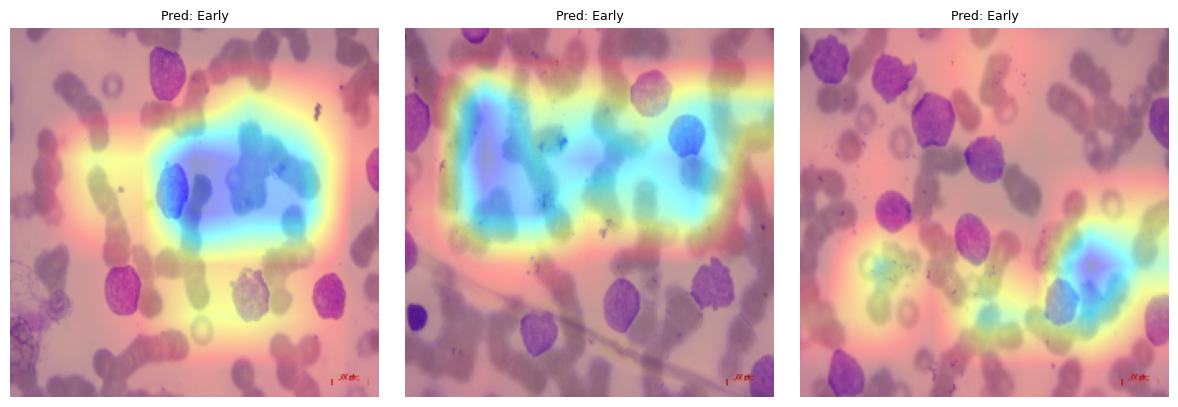


Class: Pre


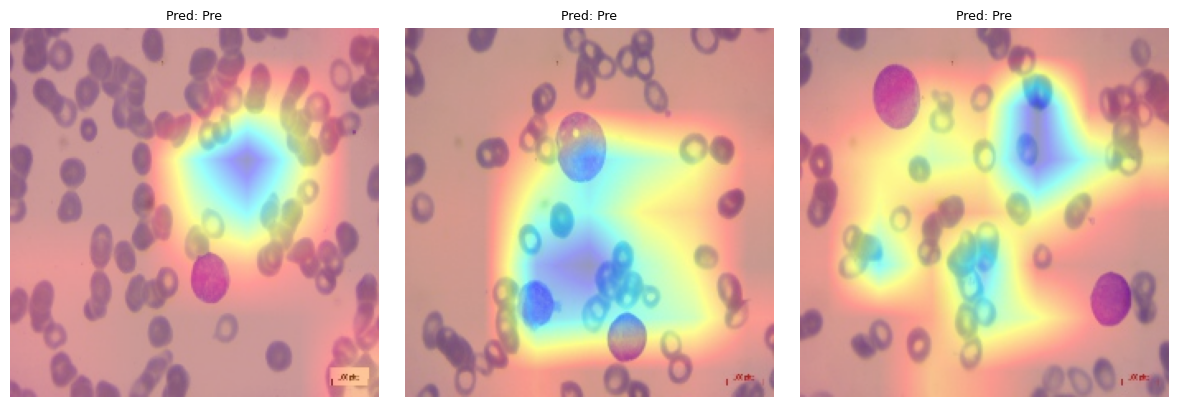


Class: Pro


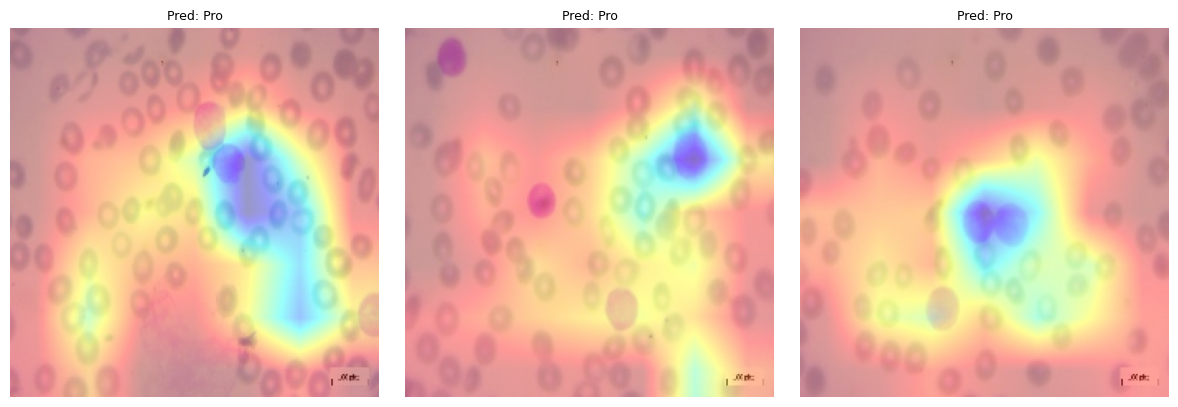

In [92]:
images_per_class = 3

for cls in classes:
    cls_path = os.path.join(test_dir, cls)
    img_names = os.listdir(cls_path)[:images_per_class]

    print(f"\nClass: {cls}")

    plt.figure(figsize=(12, 4))

    for i, img_name in enumerate(img_names):
        img_path = os.path.join(cls_path, img_name)
        img = Image.open(img_path).convert("RGB")

        x = test_transform(img).unsqueeze(0).to(device)

        with torch.no_grad():
            logits = model(x)
            pred = logits.argmax(dim=1).item()

        cam, _ = gradcam.generate(x, pred)

        img_np = np.array(img.resize((224, 224)))
        heatmap = cv2.applyColorMap(
            np.uint8(255 * cam), cv2.COLORMAP_JET
        )
        overlay = cv2.addWeighted(img_np, 0.6, heatmap, 0.4, 0)

        plt.subplot(1, images_per_class, i + 1)
        plt.imshow(overlay)
        plt.title(f"Pred: {class_names[pred]}", fontsize=9)
        plt.axis("off")

    plt.tight_layout()
    plt.show()
